In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from upsetplot import UpSet, from_memberships

In [2]:
uw_metadata = pd.read_csv("/home/Users/rdd4/bronko/test_data/UW_influenza/metadata.csv")

In [3]:
uw = pd.read_csv("/home/Users/rdd4/bronko/test_outputs/UW_influenza/overview.tsv", delimiter="\t")
uw

,Sample,BT2_Time,BT2_LoFreq_Time,BT2_iVar_Time,Bronko_Time,Minor_TP_LoFreq,Minor_FP_LoFreq,Minor_FN_LoFreq,Minor_Precision_LoFreq,Minor_Recall_LoFreq,...,Minor_Shared_iVar,Minor_Unique_Bronko,Minor_Unique_LoFreq,Minor_Unique_iVar,Major_Shared_All,Major_Shared_LoFreq,Major_Shared_iVar,Major_Unique_Bronko,Major_Unique_LoFreq,Major_Unique_iVar
0,SRR33673662,NaN,NaN,NaN,3.31,6,0,1,1.0000,0.8571,...,6,0,0,29,0,0,0,0,0,0
1,SRR33673663,NaN,NaN,NaN,3.71,2,4,4,0.3333,0.3333,...,3,3,0,337,69,69,69,0,0,0
2,SRR33673664,NaN,NaN,NaN,3.59,13,2,13,0.8667,0.5000,...,14,1,0,196,68,68,68,0,0,0
3,SRR33673665,NaN,NaN,NaN,3.39,3,3,5,0.5000,0.3750,...,3,3,0,60,70,70,70,0,0,0
4,SRR33673666,NaN,NaN,NaN,3.43,3,3,4,0.5000,0.4286,...,3,3,0,337,67,67,67,0,0,0
5,SRR33673667,NaN,NaN,NaN,3.25,9,2,3,0.8182,0.7500,...,9,2,0,95,67,67,67,0,0,0
6,SRR33673668,NaN,NaN,NaN,3.21,3,2,1,0.6000,0.7500,...,4,1,0,51,63,63,63,0,0,0
7,SRR33673669,NaN,NaN,NaN,3.43,8,4,4,0.6667,0.6667,...,9,3,0,38,62,62,62,0,0,0
8,SRR33673670,NaN,NaN,NaN,3.24,2,4,2,0.3333,0.5000,...,3,3,0,125,82,82,82,0,0,0
9,SRR33673671,NaN,NaN,NaN,3.55,6,2,18,0.7500,0.2500,...,7,1,0,304,62,62,62,0,0,0


In [4]:
uw['Minor_Precision_LoFreq']

0     1.0000
1     0.3333
2     0.8667
3     0.5000
4     0.5000
5     0.8182
6     0.6000
7     0.6667
8     0.3333
9     0.7500
10    0.5000
11    0.7778
12    0.5714
Name: Minor_Precision_LoFreq, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x7f2827604890>,
 'caps': [<matplotlib.lines.Line2D at 0x7f2827604dd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f28275cb200>,
 'medians': [<matplotlib.lines.Line2D at 0x7f28276053d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f28276056a0>,
 'means': []}

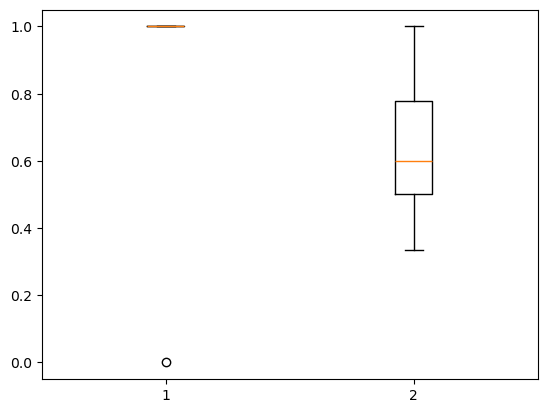

In [5]:
plt.boxplot(uw[['Major_Precision_LoFreq', 'Minor_Precision_LoFreq']])

In [6]:
def compare_runtime(data):
    df = data[['Bronko_Time','BT2_Time', 'BT2_LoFreq_Time', 'BT2_iVar_Time']]
    df_long = df.reset_index().melt(id_vars="index", var_name="Tool", value_name="Runtime")
    plt.figure(figsize=(max(8, len(df.columns)), 6))

    # Boxplot for each column
    ax = sns.boxplot(data=df_long, x="Tool", y="Runtime", palette="light:#5A9", showfliers=False)

    # Scatter (strip) plot on top
    sns.stripplot(data=df_long, x="Tool", y="Runtime", color="black", size=4, jitter=True, alpha=0.6)

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.title("Runtimes by tool")
    plt.ylabel("Runtime (s)")
    plt.xlabel("Tool")
    plt.yscale("log")
    ax.set_xticks(ticks=range(len(df.columns)),labels=['bronko','Bowtie2 (No Variant Calling)', 'Bowtie2+LoFreq', 'Bowtie2+iVar'])
    plt.show()

/tmp/ipykernel_2170824/1034931902.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_long, x="Tool", y="Runtime", palette="light:#5A9", showfliers=False)


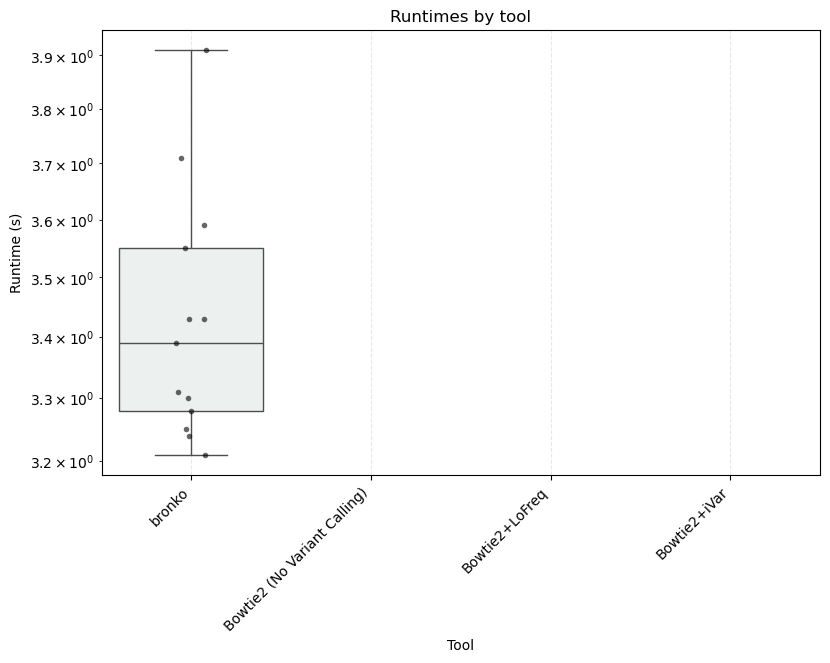

In [7]:
compare_runtime(uw)

In [8]:

major = pd.read_csv("/home/Users/rdd4/bronko/test_outputs/UW_influenza/major_variants.tsv", delimiter="\t")
minor = pd.read_csv("/home/Users/rdd4/bronko/test_outputs/UW_influenza/minor_variants.tsv", delimiter="\t")
major

,Sample,reference,index,ref,tools,A_bt2,C_bt2,G_bt2,T_bt2,a_bt2,...,g_bt2,t_bt2,A_bronko,C_bronko,G_bronko,T_bronko,a_bronko,c_bronko,g_bronko,t_bronko
0,SRR33673663,PV249929.1,166,G,"bronko,ivar,lofreq",20864,37,16,0,16608,...,9,23,18883,0,16,0,14693,0,0,15
1,SRR33673663,PV249929.1,214,T,"bronko,ivar,lofreq",5,19625,0,17,8,...,7,10,0,14989,0,0,0,21686,0,0
2,SRR33673663,PV249929.1,288,G,"bronko,ivar,lofreq",23507,11,30,10,24934,...,49,21,17714,0,18,0,18888,0,38,0
3,SRR33673663,PV249929.1,315,A,"bronko,ivar,lofreq",9,1,23087,2,5,...,23490,24,0,0,20946,0,0,0,20765,11
4,SRR33673663,PV249929.1,414,C,"bronko,ivar,lofreq",7,39,1,18156,2,...,1,13141,0,32,0,15873,0,17,0,10682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922,SRR33673675,PV249936.1,552,G,"bronko,ivar,lofreq",2816,0,1,3,2198,...,0,1,2183,0,0,0,1545,0,0,0
923,SRR33673675,PV249936.1,741,G,"bronko,ivar,lofreq",1,2,0,2980,1,...,0,3258,0,0,0,2505,0,0,0,2997
924,SRR33673675,PV249936.1,849,A,"bronko,ivar,lofreq",1,1,3670,9,3,...,2694,1,0,0,2874,0,0,0,2132,0
925,SRR33673675,PV249936.1,1465,A,"bronko,ivar,lofreq",9,0,4160,1,2,...,4195,1,0,0,3871,0,0,12,3293,0


In [9]:
def upset_plot_variants(data):
    df = data
    tool_data = df['tools'].str.split(',')
    tool_data = from_memberships(tool_data)
    fig = plt.figure(figsize=(12, 8))
    UpSet(tool_data, subset_size='count', facecolor="darkblue", shading_color="lightgray", show_counts="%d", sort_by="cardinality").plot(fig=fig)
    plt.suptitle("Variants shared between each method")
    plt.ylabel("Number of Variants")

/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

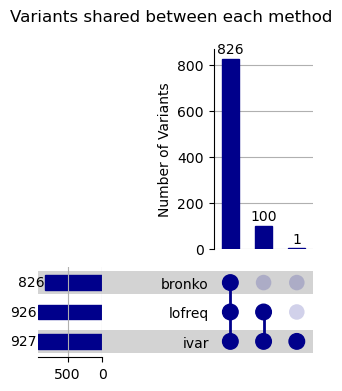

In [10]:
upset_plot_variants(major)

/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

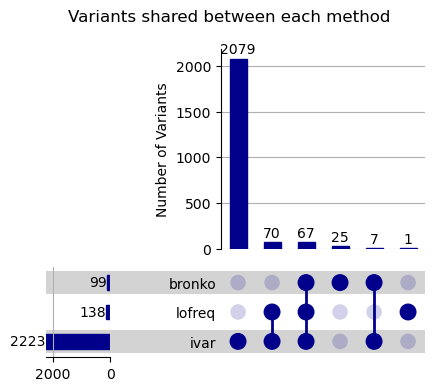

In [11]:
upset_plot_variants(minor)

In [14]:
# Helper to get depth, major, minor, and MAF
def compute_stats_with_counts(row, suffix):
    bases = ['A', 'C', 'G', 'T']
    counts = [row[f"{b.upper()}_{suffix}"] + row[f"{b.lower()}_{suffix}"] for b in bases]
    depth = sum(counts)
    sorted_counts = sorted(zip(bases, counts), key=lambda x: x[1], reverse=True)
    major, major_count = sorted_counts[0]
    minor, minor_count = sorted_counts[1]
    maf = minor_count / depth if depth > 0 else 0
    return pd.Series([
        depth,
        major,
        major_count,
        minor,
        minor_count,
        maf
    ], index=[
        f'{suffix}_depth',
        f'{suffix}_major',
        f'{suffix}_major_count',
        f'{suffix}_minor',
        f'{suffix}_minor_count',
        f'{suffix}_maf'
    ])


# Compute IV stats
def get_columns(variants):
    variants = variants.join(variants.apply(compute_stats_with_counts, axis=1, suffix='bronko'))
    variants = variants.join(variants.apply(compute_stats_with_counts, axis=1, suffix='bt2'))

    # Compute differences
    variants['Depth Difference'] = variants['bt2_depth'] - variants['bronko_depth']
    variants['maf difference'] = variants['bt2_maf'] - variants['bronko_maf']

    # Reorder columns (optional)
    desired_order = [
        'Sample', 'reference', 'index', 'ref', 'tools',
        'Depth Difference', 'maf difference',
        'bronko_depth', 'bronko_major', 'bronko_major_count','bronko_minor', 'bronko_minor_count','bronko_maf', 'A_bronko', 'C_bronko', 'G_bronko', 'T_bronko', 'a_bronko', 'c_bronko', 'g_bronko', 't_bronko',
        'bt2_depth', 'bt2_major', 'bt2_major_count','bt2_minor', 'bt2_minor_count', 'bt2_maf', 'A_bt2', 'C_bt2', 'G_bt2', 'T_bt2', 'a_bt2', 'c_bt2', 'g_bt2', 't_bt2'
    ]

    variants = variants[desired_order]
    return variants

In [15]:
major_all_stats = get_columns(major)
minor_all_stats = get_columns(minor)
minor_all_stats

,Sample,reference,index,ref,tools,Depth Difference,maf difference,bronko_depth,bronko_major,bronko_major_count,...,bt2_minor_count,bt2_maf,A_bt2,C_bt2,G_bt2,T_bt2,a_bt2,c_bt2,g_bt2,t_bt2
0,SRR33673662,PV249929.1,520,A,"ivar,lofreq",2123,0.000523,17469,A,17290,...,211,0.010770,6543,1,56,4,12807,12,155,14
1,SRR33673662,PV249929.1,1556,A,ivar,5357,0.011161,19998,A,19983,...,302,0.011911,12725,0,11,278,12306,2,9,24
2,SRR33673662,PV249929.1,1655,T,ivar,6037,0.004303,22190,T,22041,...,297,0.010522,3,9,4,8208,0,288,270,19445
3,SRR33673662,PV249929.1,1657,T,ivar,7101,0.010018,21692,T,21675,...,311,0.010801,10,11,0,8394,3,20,311,20044
4,SRR33673662,PV249931.1,82,T,"bronko,ivar,lofreq",1638,0.012612,14701,T,11701,...,3527,0.215864,14,2491,8,9029,0,1036,5,3756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,SRR33673675,PV249936.1,2134,A,ivar,19843,0.299206,41333,A,41272,...,18356,0.300052,15818,41,7602,634,25560,7,10754,760
2245,SRR33673675,PV249936.1,2135,G,ivar,20385,0.017223,41282,G,41272,...,1077,0.017465,35,49,23755,510,37,32,36682,567
2246,SRR33673675,PV249936.1,2136,A,ivar,22767,0.037989,41291,A,41272,...,2463,0.038450,24574,1,1685,19,36974,7,778,20
2247,SRR33673675,PV249936.1,2137,T,ivar,22032,0.038769,41184,T,41152,...,2480,0.039231,1693,3,21,24233,787,12,15,36452


In [ ]:
def plot_maf_comparison(minor_all_stats):
    """
    Plot two side-by-side MAF comparison scatterplots:
    - Left: full range (0–0.5)
    - Right: zoomed in (0–0.1)

    Parameters:
        minor_all_stats (pd.DataFrame): DataFrame with columns 'bt2_maf', 'bronko_maf', and 'tools'
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    minor_all_stats = minor_all_stats.sort_values(by='tools')

    # Full-range plot
    sns.scatterplot(
        data=minor_all_stats,
        x='bt2_maf', y='bronko_maf',
        hue='tools', ax=axes[0],
    )
    axes[0].plot([0, 1], [0, 1], 'k-', alpha=0.75, zorder=0)
    axes[0].axhline(0, color='black')
    axes[0].axvline(0, color='black')
    axes[0].set_xlim([0, 0.5])
    axes[0].set_ylim([0, 0.5])
    axes[0].set_ylabel("bronko Minor Allele Frequency")
    axes[0].set_xlabel("Bowtie2 Pileup Minor Allele Frequency")
    axes[0].set_title("MAF Comparison (0–0.5)")
    axes[0].get_legend().remove()

    # Zoomed-in plot
    sns.scatterplot(
        data=minor_all_stats,
        x='bt2_maf', y='bronko_maf',
        hue='tools', ax=axes[1], legend=False
    )
    axes[1].plot([0, 1], [0, 1], 'k-', alpha=0.75, zorder=0)
    axes[1].axhline(0, color='black')
    axes[1].axvline(0, color='black')
    axes[1].set_xlim([0, 0.1])
    axes[1].set_ylim([0, 0.1])
    axes[1].set_xlabel("Bowtie2 Pileup Minor Allele Frequency")
    axes[1].set_ylabel("")
    axes[1].set_title("MAF Comparison (0–0.1)")

    # Shared legend above plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Variant Identified", loc='right', bbox_to_anchor=(1.12, 0.5))

    plt.tight_layout()
    plt.show()
    
    
def plot_count_comparison(minor_all_stats):
    """
    Plot two side-by-side MAF comparison scatterplots:
    - Left: full range (0–0.5)
    - Right: zoomed in (0–0.1)

    Parameters:
        minor_all_stats (pd.DataFrame): DataFrame with columns 'bt2_maf', 'bronko_maf', and 'tools'
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    minor_all_stats['adj_bronko_minor_count'] = minor_all_stats['bronko_minor_count'] / 0.85

    
    minor_all_stats = minor_all_stats.sort_values(by='tools')

    # Full-range plot
    sns.scatterplot(
        data=minor_all_stats,
        x='bt2_minor_count', y='adj_bronko_minor_count',
        hue='tools', ax=axes[0][0],
    )
    max_count = max(minor_all_stats['bt2_minor_count'].max(), minor_all_stats['adj_bronko_minor_count'].max())
    axes[0][0].plot([0, max_count], [0, max_count], 'k-', alpha=0.75, zorder=0)
    axes[0][0].axhline(0, color='black')
    axes[0][0].axvline(0, color='black')
    axes[0][0].set_xlim([0, max_count])
    axes[0][0].set_ylim([0, max_count])
    axes[0][0].set_ylabel("bronko Pileup Minor Allele Count")
    axes[0][0].set_xlabel("Bowtie2 Pileup Minor Allele Count")
    axes[0][0].set_title("Minor Allele Count Comparison")
    
        # Full-range plot
    sns.scatterplot(
        data=minor_all_stats,
        x='bt2_minor_count', y='adj_bronko_minor_count',
        hue='tools', ax=axes[0][1],
    )
    max_count = max(minor_all_stats['bt2_minor_count'].quantile(q=0.95).max(), minor_all_stats['adj_bronko_minor_count'].quantile(q=0.95).max())
    axes[0][1].plot([0, max_count], [0, max_count], 'k-', alpha=0.75, zorder=0)
    axes[0][1].axhline(0, color='black')
    axes[0][1].axvline(0, color='black')
    axes[0][1].set_xlim([0, max_count])
    axes[0][1].set_ylim([0, max_count])
    axes[0][1].set_ylabel("bronko Pileup Minor Allele Count")
    axes[0][1].set_xlabel("Bowtie2 Pileup Minor Allele Count")
    axes[0][1].set_title("Minor Allele Count Comparison")

    minor_all_stats['adj_bronko_major_count'] = minor_all_stats['bronko_major_count'] * 100 / (100-19+1)
    
    # Zoomed-in plot
    sns.scatterplot(
        data=minor_all_stats,
        x='bt2_major_count', y='adj_bronko_major_count',
        hue='tools', ax=axes[1][0], legend=False
    )
    max_count = max(minor_all_stats['bt2_major_count'].max(), minor_all_stats['adj_bronko_major_count'].max())
    axes[1][0].plot([0, max_count], [0, max_count], 'k-', alpha=0.75, zorder=0)
    axes[1][0].axhline(0, color='black')
    axes[1][0].axvline(0, color='black')
    axes[1][0].set_xlim([0, max_count])
    axes[1][0].set_ylim([0, max_count])
    axes[1][0].set_xlabel("Bowtie2 Pileup Major Allele Count")
    axes[1][0].set_ylabel("bronko Pileup Minor Allele Count")
    axes[1][0].set_title("Major Allele Count Comparison")
    
    
            # Full-range plot
    sns.scatterplot(
        data=minor_all_stats,
        x='bt2_major_count', y='bronko_major_count',
        hue='tools', ax=axes[1][1],
    )
    max_count = max(minor_all_stats['bt2_major_count'].quantile(q=0.95).max(), minor_all_stats['bronko_major_count'].quantile(q=0.95).max())
    axes[1][1].plot([0, max_count], [0, max_count], 'k-', alpha=0.75, zorder=0)
    axes[1][1].axhline(0, color='black')
    axes[1][1].axvline(0, color='black')
    axes[1][1].set_xlim([0, max_count])
    axes[1][1].set_ylim([0, max_count])
    axes[1][1].set_ylabel("bronko Pileup Major Allele Count")
    axes[1][1].set_xlabel("Bowtie2 Pileup Major Allele Count")
    axes[1][1].set_title("Major Allele Count Comparison")

    # Shared legend above plots
    # handles, labels = axes[0].get_legend_handles_labels()
    # fig.legend(handles, labels, title="Variant Identified", loc='right', bbox_to_anchor=(1.12, 0.5))

    plt.tight_layout()
    plt.show()
    

    

/tmp/ipykernel_2170824/1696275167.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  minor_all_stats['adj_bronko_minor_count'] = minor_all_stats['bronko_minor_count'] / 0.85


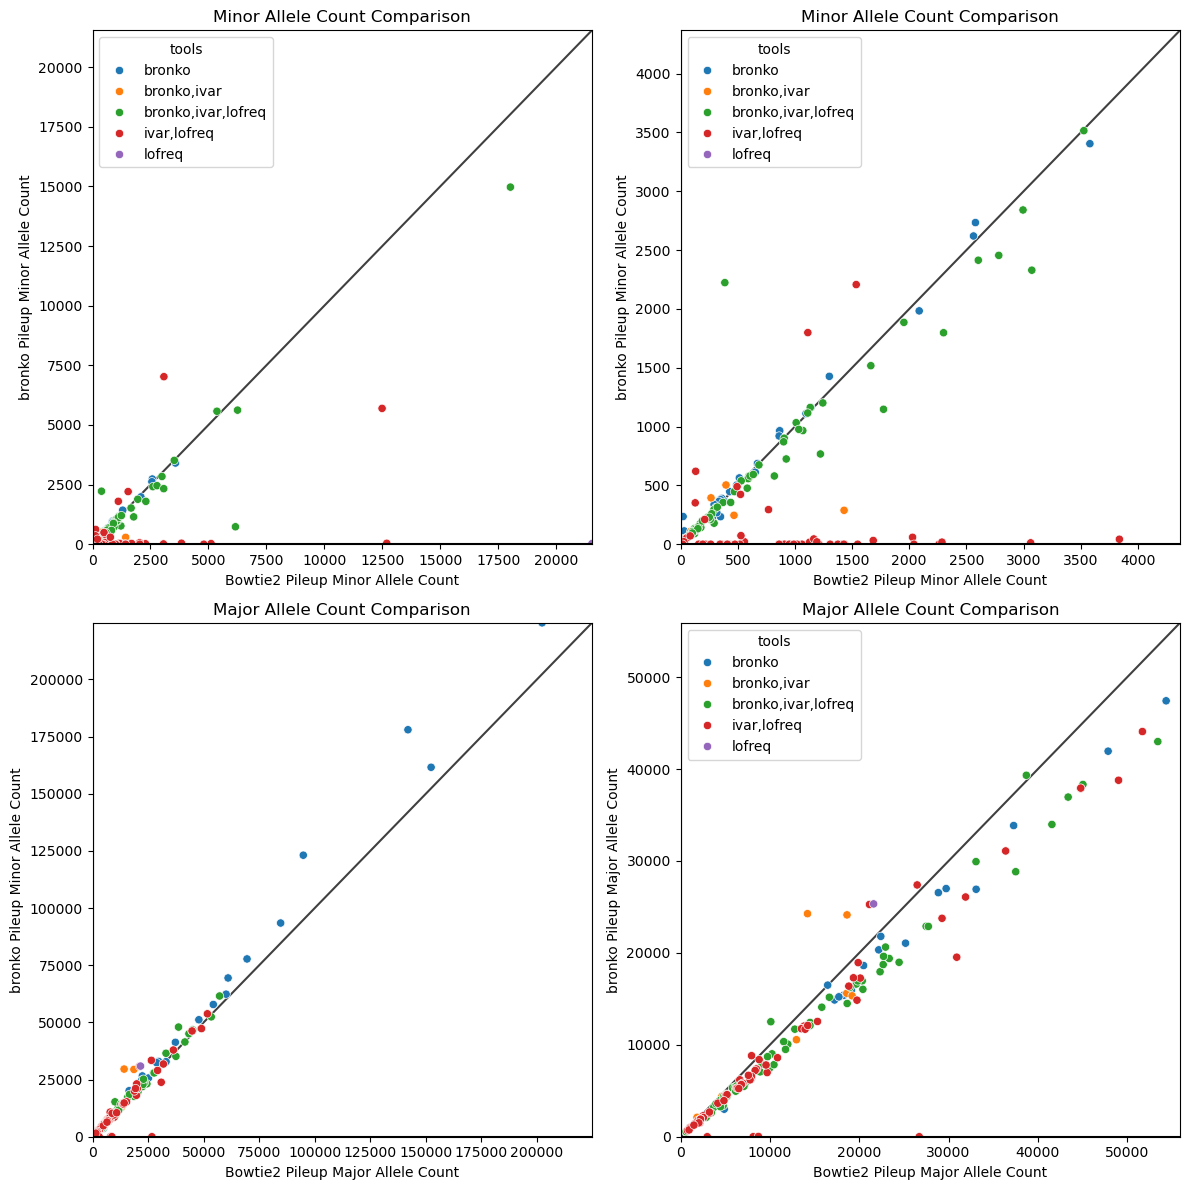

In [39]:
plot_count_comparison(minor_all_stats[minor_all_stats['tools'] != 'ivar'])

In [26]:
import numpy as np
test_data = minor_all_stats[(minor_all_stats['tools'] != 'ivar') | (minor_all_stats['tools'] != 'ivar,lofreq')]
# test_data = minor_all_stats
m, b = np.polyfit(test_data['bt2_minor_count'], test_data['bronko_minor_count'], 1)
m, b

(np.float64(0.04615807675241073), np.float64(21.088076050046293))

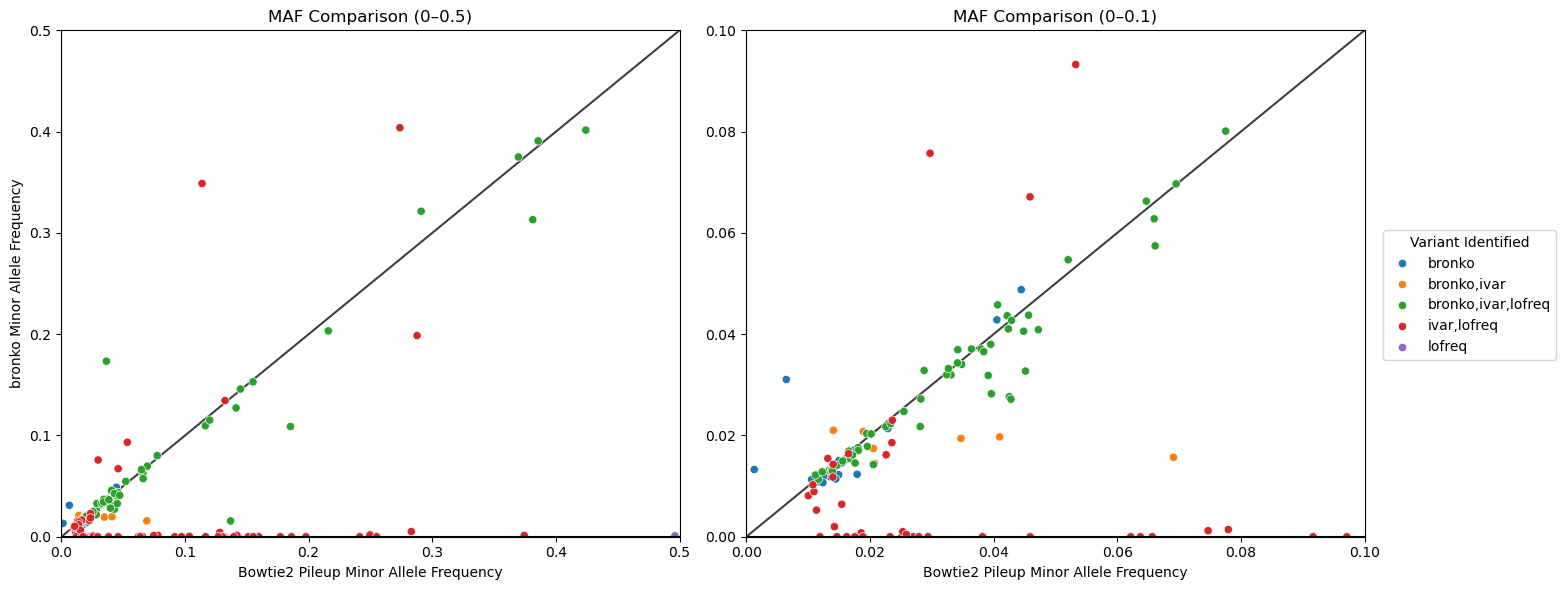

In [20]:
plot_maf_comparison(minor_all_stats[minor_all_stats['tools'] != 'ivar'])

In [98]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
minor_all_stats[(minor_all_stats['tools']=='ivar,lofreq')]

,Sample,reference,index,ref,tools,Depth Difference,maf difference,bronko_depth,bronko_major,bronko_major_count,bronko_minor,bronko_minor_count,bronko_maf,A_bronko,C_bronko,G_bronko,T_bronko,a_bronko,c_bronko,g_bronko,t_bronko,bt2_depth,bt2_major,bt2_major_count,bt2_minor,bt2_minor_count,bt2_maf,A_bt2,C_bt2,G_bt2,T_bt2,a_bt2,c_bt2,g_bt2,t_bt2
0,SRR33673662,PV249929.1,520,A,"ivar,lofreq",2123,0.000523,17469,A,17290,G,179,0.010247,5933,0,48,0,11357,0,131,0,19592,A,19350,G,211,0.010770,6543,1,56,4,12807,12,155,14
42,SRR33673663,PV249929.1,1607,A,"ivar,lofreq",8066,0.024317,37948,A,37885,G,38,0.001001,17854,0,11,0,20031,0,27,25,46014,A,44788,T,1165,0.025318,20438,11,17,400,24350,4,29,765
43,SRR33673663,PV249929.1,1608,C,"ivar,lofreq",8092,0.025440,37952,C,37924,A,17,0.000448,0,17867,0,0,17,20057,0,11,46044,C,44788,G,1192,0.025888,4,20434,426,20,23,24354,766,17
56,SRR33673663,PV249933.1,695,A,"ivar,lofreq",1935,0.016228,7801,A,7801,C,0,0.000000,3128,0,0,0,4673,0,0,0,9736,A,9563,T,158,0.016228,3713,2,3,32,5850,3,7,126
274,SRR33673663,PV249935.1,160,A,"ivar,lofreq",2647,0.076549,18963,A,18936,G,27,0.001424,13052,0,17,0,5884,0,10,0,21610,A,19879,C,1685,0.077973,13040,952,23,1,6839,733,15,7
385,SRR33673664,PV249929.1,1160,G,"ivar,lofreq",1606,0.025977,6555,G,6555,A,0,0.000000,0,0,3732,0,0,0,2823,0,8161,G,7936,C,212,0.025977,6,134,4524,2,4,78,3412,1
386,SRR33673664,PV249929.1,1162,C,"ivar,lofreq",1807,0.027024,6186,C,6186,A,0,0.000000,0,3387,0,0,0,2799,0,0,7993,C,7771,A,216,0.027024,135,4454,3,3,81,3317,0,0
392,SRR33673664,PV249930.1,598,A,"ivar,lofreq",7813,0.001927,44458,A,44075,G,360,0.008098,23089,0,177,0,20986,0,183,23,52271,A,51693,G,524,0.010025,27153,6,287,17,24540,1,237,30
409,SRR33673664,PV249931.1,1373,A,"ivar,lofreq",223,0.004974,754,A,740,G,14,0.018568,221,0,0,0,519,0,14,0,977,A,953,G,23,0.023541,307,0,8,0,646,0,15,1
431,SRR33673664,PV249934.1,514,G,"ivar,lofreq",140,0.018831,869,G,869,A,0,0.000000,0,0,310,0,0,0,559,0,1009,G,990,A,19,0.018831,8,0,367,0,11,0,623,0


In [102]:
pd.set_option('display.max_columns', None)
minor_all_stats[minor_all_stats['tools']=='bronko'].sort_values(by='maf difference')

,Sample,reference,index,ref,tools,Depth Difference,maf difference,bronko_depth,bronko_major,bronko_major_count,bronko_minor,bronko_minor_count,bronko_maf,A_bronko,C_bronko,G_bronko,T_bronko,a_bronko,c_bronko,g_bronko,t_bronko,bt2_depth,bt2_major,bt2_major_count,bt2_minor,bt2_minor_count,bt2_maf,A_bt2,C_bt2,G_bt2,T_bt2,a_bt2,c_bt2,g_bt2,t_bt2
773,SRR33673666,PV249934.1,1832,A,bronko,1857,-0.024582,3092,A,2996,G,96,0.031048,1689,0,51,0,1307,0,45,0,4949,A,4882,G,32,0.006466,3032,1,6,25,1850,4,26,5
616,SRR33673665,PV249931.1,917,C,bronko,2194,-0.011993,15075,C,14875,A,200,0.013267,157,7588,0,0,43,7287,0,0,17269,C,17231,A,22,0.001274,9,8868,0,5,13,8363,10,1
1291,SRR33673670,PV249932.1,499,A,bronko,2690,-0.004321,16806,A,15216,C,820,0.048792,5985,820,489,241,9231,0,28,12,19496,A,17719,C,867,0.044471,7081,865,587,272,10638,2,32,19
1290,SRR33673670,PV249932.1,499,A,bronko,2690,-0.004321,16806,A,15216,C,820,0.048792,5985,820,489,241,9231,0,28,12,19496,A,17719,C,867,0.044471,7081,865,587,272,10638,2,32,19
1029,SRR33673667,PV249930.1,64,T,bronko,9363,-0.002293,54273,T,51116,A,2324,0.042821,0,30,0,40191,2324,515,288,10925,63636,T,60100,A,2579,0.040527,18,34,2,45899,2561,597,324,14201
925,SRR33673666,PV249935.1,2189,C,bronko,6266,-0.000734,42419,C,41940,G,479,0.011292,0,16501,468,0,0,25439,11,0,48685,C,47855,G,514,0.010558,80,18742,499,43,116,29113,15,77
1725,SRR33673672,PV249936.1,82,A,bronko,1899,-0.000205,18944,A,18622,T,322,0.016997,13127,0,0,308,5495,0,0,14,20843,A,20483,T,350,0.016792,14149,0,8,328,6334,0,2,22
1244,SRR33673669,PV249936.1,2039,A,bronko,1890,-0.000062,20637,A,20327,T,310,0.015022,10528,0,0,300,9799,0,0,10,22527,A,22181,T,337,0.014960,11562,0,6,327,10619,0,3,10
677,SRR33673665,PV249936.1,2169,T,bronko,6254,-0.000048,27255,T,26918,A,312,0.011447,10,11,0,12414,302,14,0,14504,33509,T,33082,A,382,0.011400,15,15,0,15050,367,22,8,18032
540,SRR33673664,PV249936.1,82,A,bronko,-15,0.000373,16778,A,16491,T,287,0.017106,11804,0,0,273,4687,0,0,14,16763,A,16465,T,293,0.017479,11289,0,4,276,5176,0,1,17


In [61]:
rsv_minor = pd.read_csv('/home/Users/rdd4/bronko/test_outputs/UW_RSV/minor_variants.tsv', delimiter='\t')
rsv_major = pd.read_csv('/home/Users/rdd4/bronko/test_outputs/UW_RSV/major_variants.tsv', delimiter='\t')
rsv_overview = pd.read_csv('/home/Users/rdd4/bronko/test_outputs/UW_RSV/overview.tsv', delimiter='\t')

{'whiskers': [<matplotlib.lines.Line2D at 0x7f03e7cb3380>,
 'caps': [<matplotlib.lines.Line2D at 0x7f03e7cb3b60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f03e7cb0dd0>,
 'medians': [<matplotlib.lines.Line2D at 0x7f03f64c0530>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f03f64c3f50>,
 'means': []}

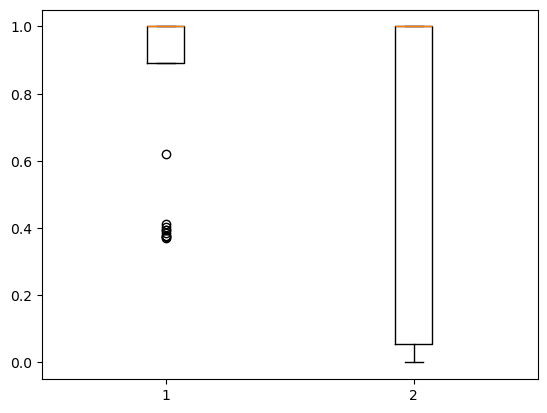

In [63]:
plt.boxplot(rsv_overview[['Major_Precision_LoFreq', 'Minor_Precision_LoFreq']])

/tmp/ipykernel_426395/1034931902.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_long, x="Tool", y="Runtime", palette="light:#5A9", showfliers=False)


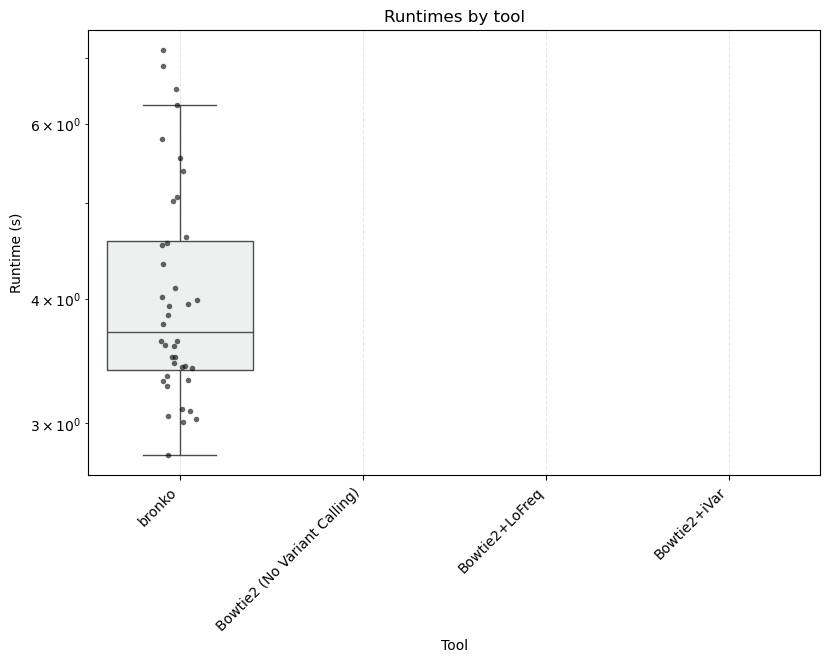

In [64]:
compare_runtime(rsv_overview)

In [65]:
major_rsv_stats = get_columns(rsv_major)
minor_rsv_stats = get_columns(rsv_minor)

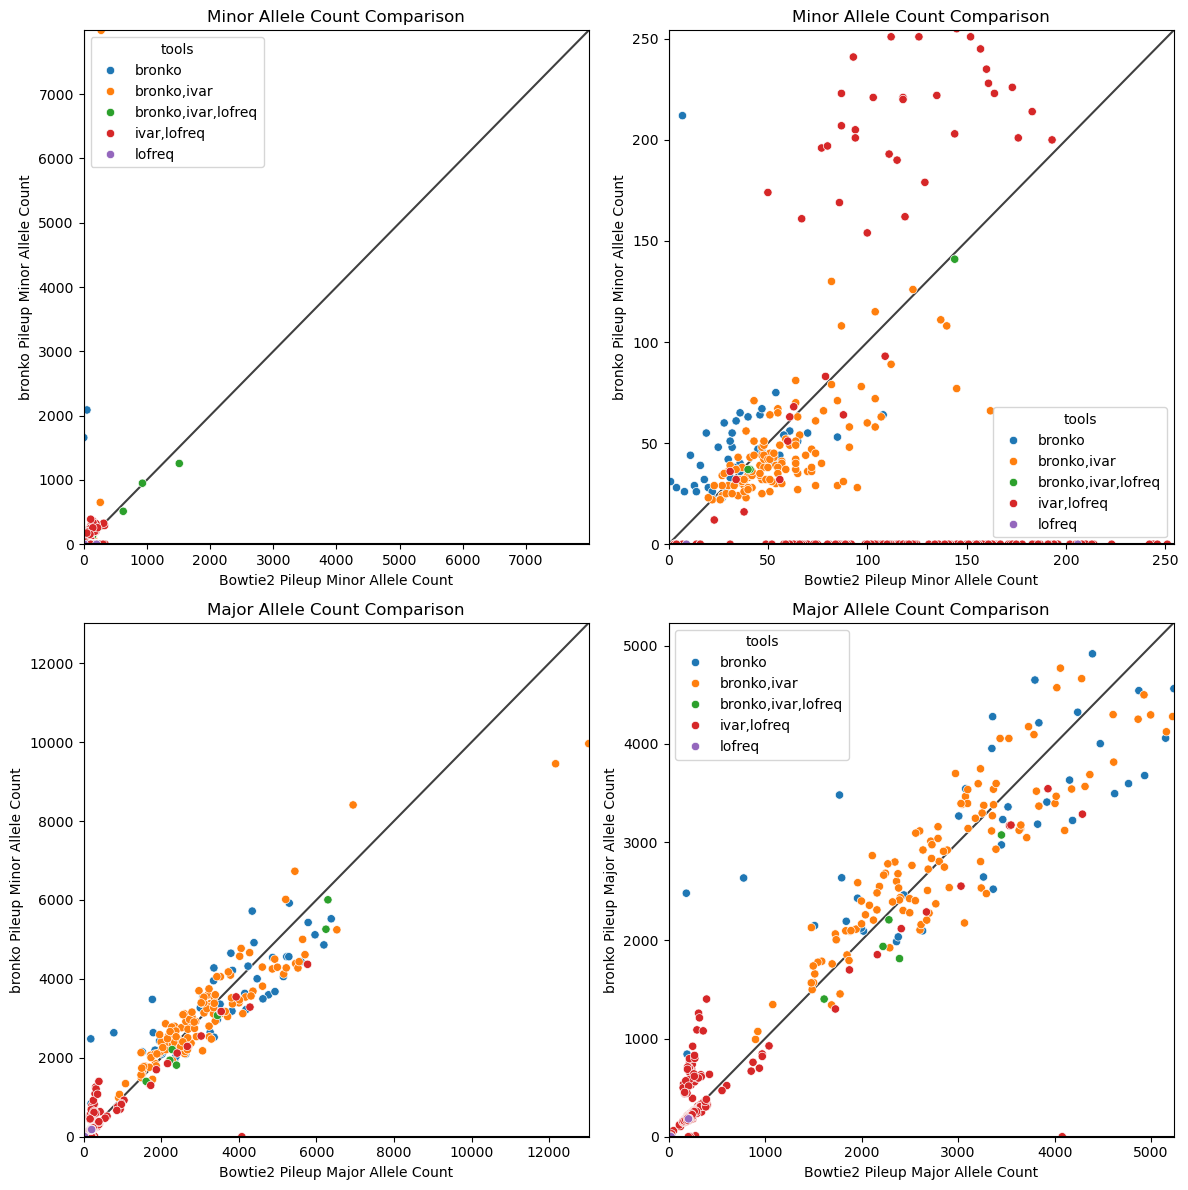

In [66]:
minor_rsv_stats_filtered = minor_rsv_stats[minor_rsv_stats['tools'] != 'ivar']
plot_count_comparison(minor_rsv_stats_filtered)

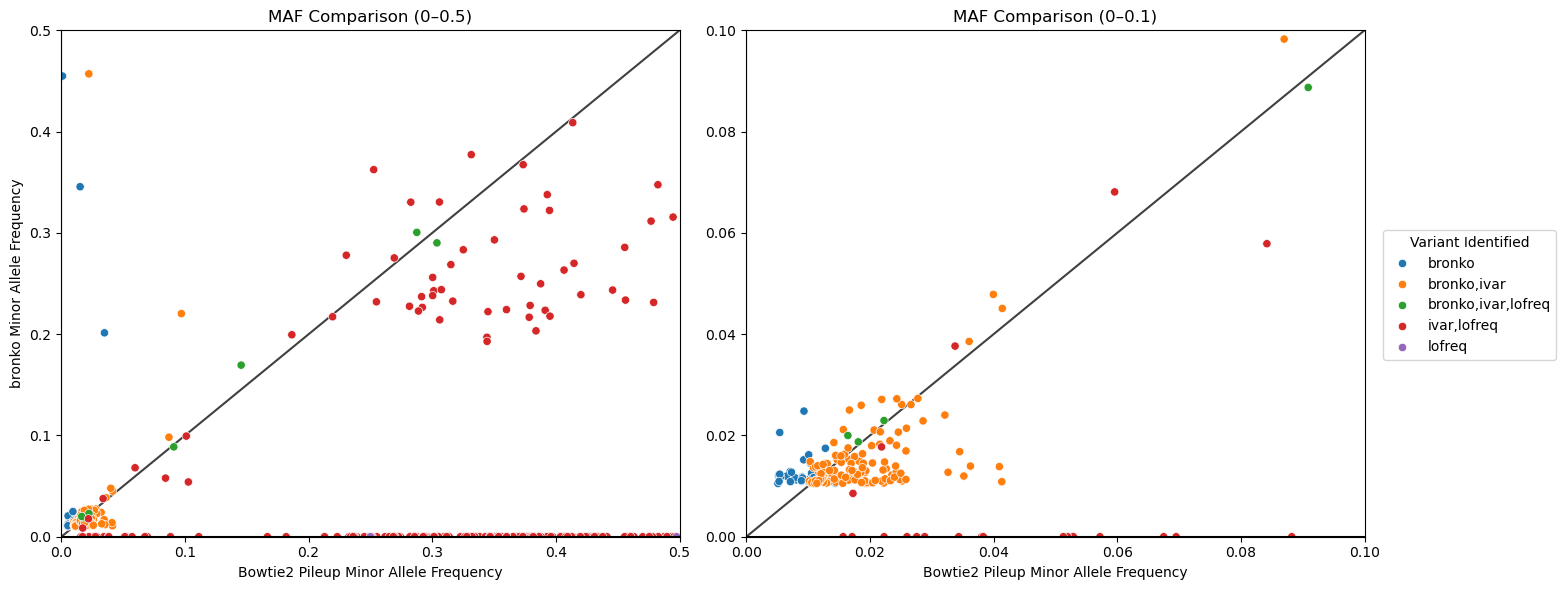

In [67]:
plot_maf_comparison(minor_rsv_stats_filtered)

/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

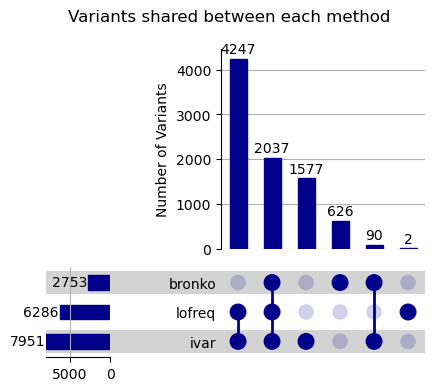

In [68]:
upset_plot_variants(rsv_major)

/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

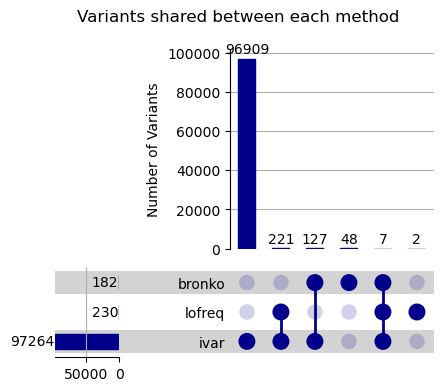

In [69]:
upset_plot_variants(rsv_minor)

In [80]:
cov_minor = pd.read_csv('/home/Users/rdd4/bronko/test_outputs/NY_biotia/minor_variants.tsv', delimiter='\t')
cov_major = pd.read_csv('/home/Users/rdd4/bronko/test_outputs/NY_biotia/major_variants.tsv', delimiter='\t')
cov_overview = pd.read_csv('/home/Users/rdd4/bronko/test_outputs/NY_biotia/overview.tsv', delimiter='\t')

/tmp/ipykernel_426395/1034931902.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_long, x="Tool", y="Runtime", palette="light:#5A9", showfliers=False)


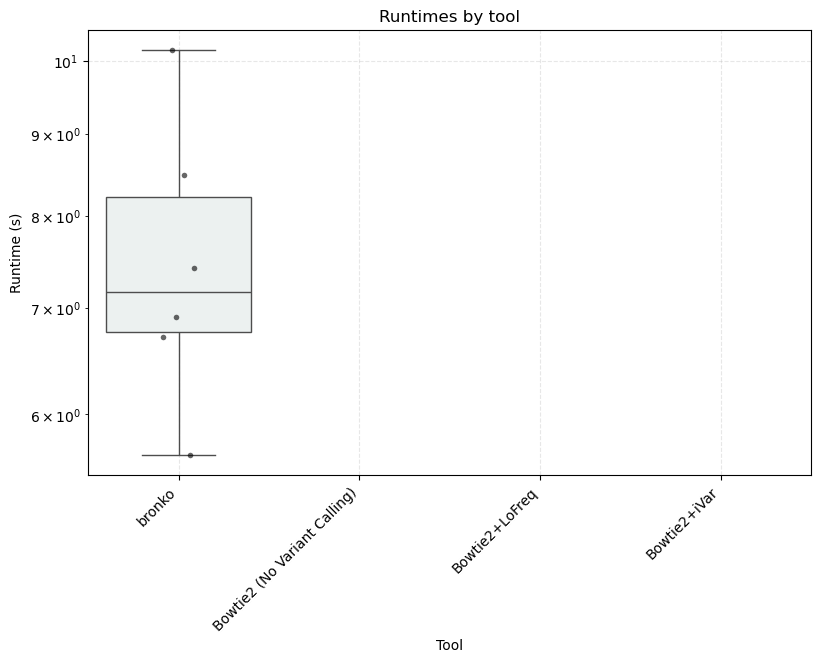

In [81]:
compare_runtime(cov_overview)

/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting va

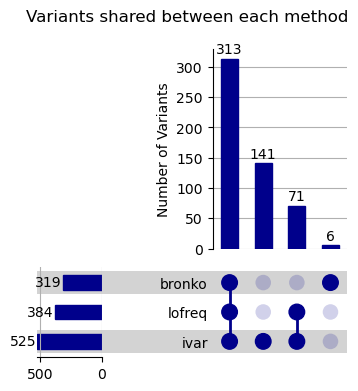

In [82]:
upset_plot_variants(cov_major)

/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Users/rdd4/conda/envs/ryan/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewid

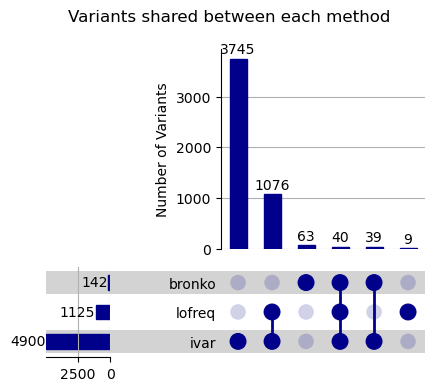

In [83]:
upset_plot_variants(cov_minor)

In [84]:
major_cov_stats = get_columns(cov_major)
minor_cov_stats = get_columns(cov_minor)

In [85]:
minor_cov_stats_filtered = minor_cov_stats[minor_cov_stats['tools'] != 'ivar']

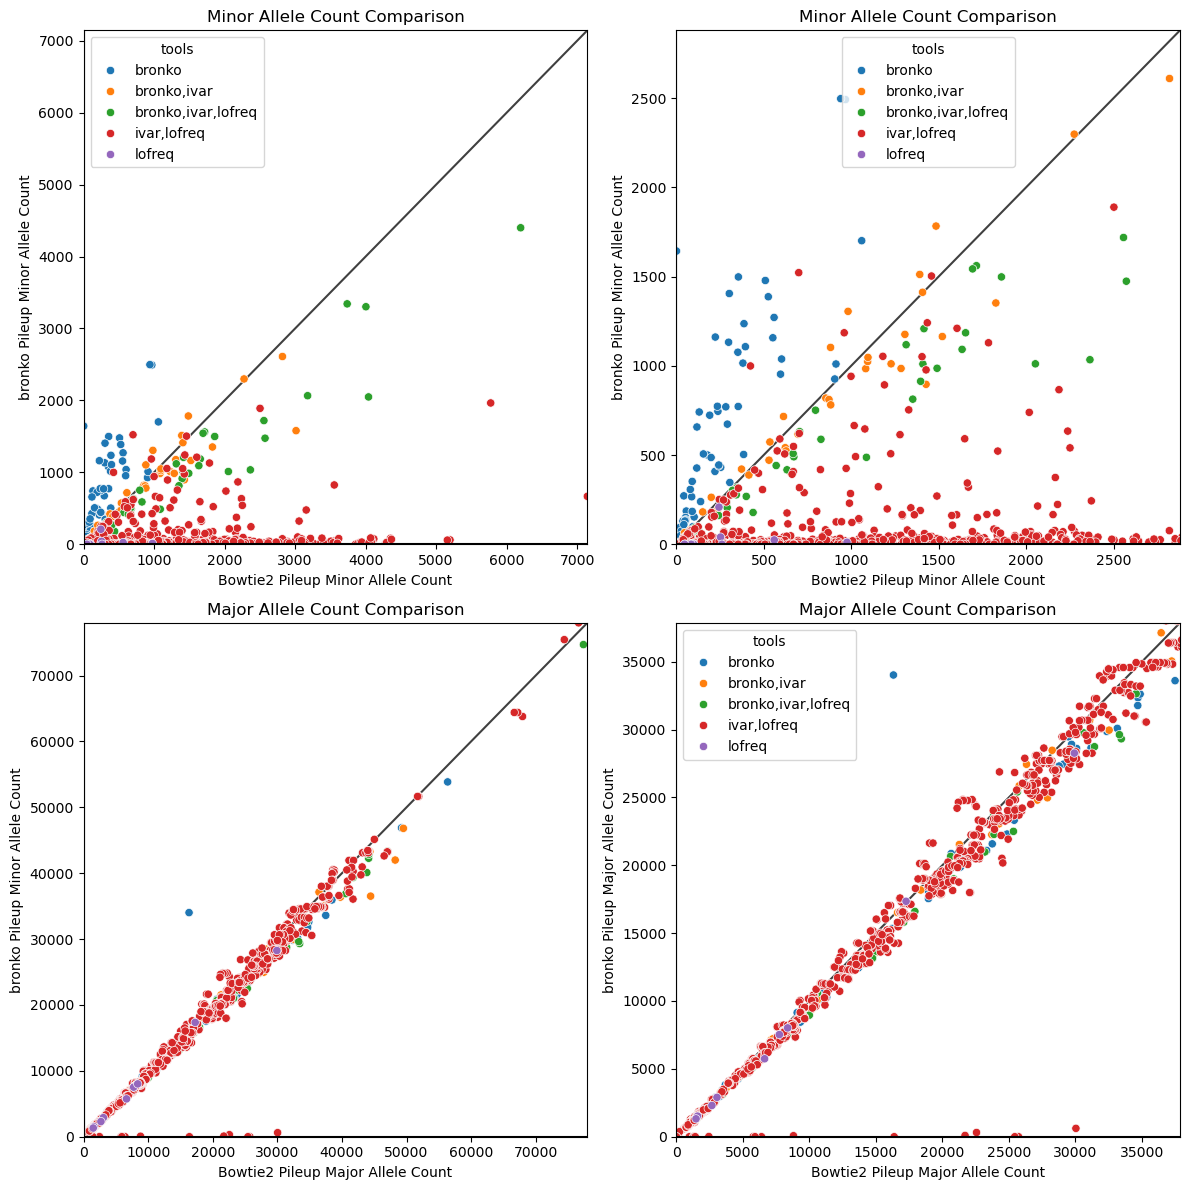

In [86]:
plot_count_comparison(minor_cov_stats_filtered)

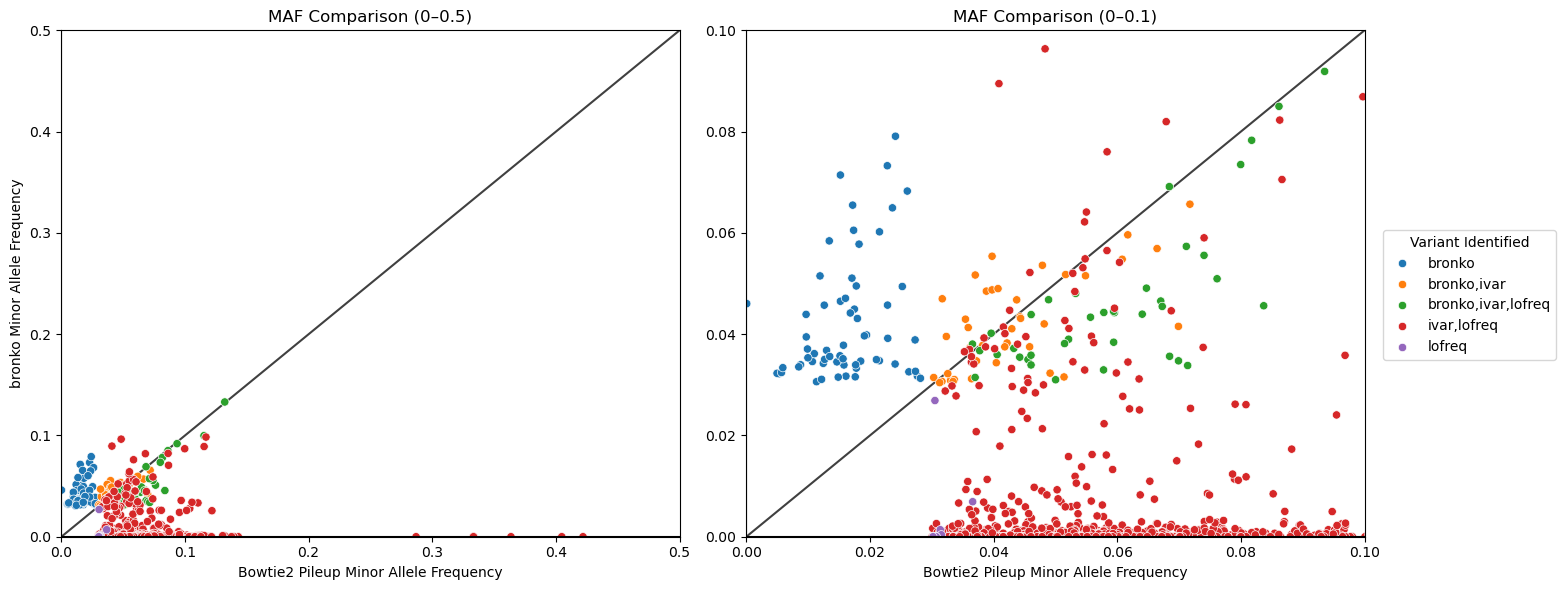

In [87]:
plot_maf_comparison(minor_cov_stats_filtered)

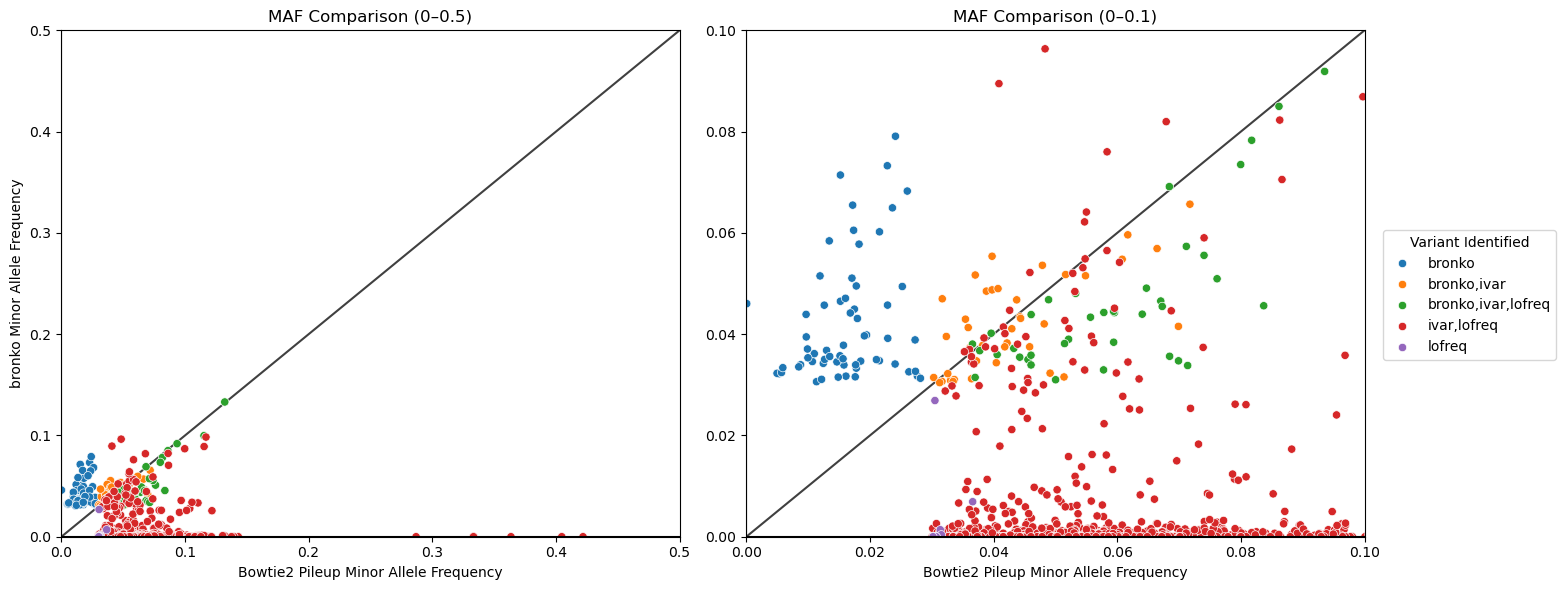

In [88]:
plot_maf_comparison(minor_cov_stats_filtered)

In [89]:
pd.set_option('display.max_columns', None)
minor_cov_stats[minor_cov_stats['tools'] == 'bronko']

,Sample,reference,index,ref,tools,Depth Difference,maf difference,bronko_depth,bronko_major,bronko_major_count,bronko_minor,bronko_minor_count,bronko_maf,A_bronko,C_bronko,G_bronko,T_bronko,a_bronko,c_bronko,g_bronko,t_bronko,bt2_depth,bt2_major,bt2_major_count,bt2_minor,bt2_minor_count,bt2_maf,A_bt2,C_bt2,G_bt2,T_bt2,a_bt2,c_bt2,g_bt2,t_bt2
11,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,1631,A,bronko,28,-0.054966,6398,A,5751,C,506,0.079087,2883,334,94,0,2868,172,47,0,6426,A,6086,C,155,0.024121,3129,57,93,25,2957,98,55,12
26,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,1821,G,bronko,1162,-0.011568,12942,G,12439,A,503,0.038866,247,0,5317,0,256,0,7122,0,14104,G,13685,A,385,0.027297,70,9,5757,11,315,7,7928,7
234,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,9396,C,bronko,236,-0.019263,4344,C,4211,T,133,0.030617,0,2075,0,96,0,2136,0,37,4580,C,4509,T,52,0.011354,13,2271,1,19,2,2238,3,33
359,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,13684,A,bronko,281,-0.048280,6521,A,6094,T,427,0.065481,2819,0,0,278,3275,0,0,149,6802,A,6678,T,117,0.017201,3248,3,3,50,3430,1,0,67
407,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,14524,A,bronko,623,-0.016184,6891,A,6652,C,239,0.034683,3212,123,0,0,3440,116,0,0,7514,A,7337,C,139,0.018499,3523,38,2,0,3814,101,9,27
437,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,15992,T,bronko,473,-0.029767,7780,T,7473,A,307,0.039460,169,0,0,3600,138,0,0,3873,8253,T,8164,A,80,0.009693,36,0,1,3919,44,8,0,4245
459,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,16602,C,bronko,552,-0.023917,7689,C,7423,A,266,0.034595,149,3487,0,0,117,3936,0,0,8241,C,8144,A,88,0.010678,19,3840,4,0,69,4304,3,2
472,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,17181,T,bronko,852,-0.015600,12867,T,12378,C,408,0.031709,57,287,0,5918,24,121,0,6460,13719,T,13359,C,221,0.016109,102,95,2,6717,31,126,4,6642
502,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,18987,T,bronko,708,-0.024185,8884,T,8445,C,439,0.049415,0,255,0,3810,0,184,0,4635,9592,T,9329,C,242,0.025229,2,69,0,4308,14,173,5,5021
543,SRR23007203,hCoV-19/USA/NY-NYS-11/2023|EPI_ISL_17612117|20...,20132,C,bronko,262,-0.027307,8397,C,8126,G,271,0.032273,0,3761,109,0,0,4365,162,0,8659,C,8581,G,43,0.004966,7,3859,20,3,0,4722,23,25
